In [1]:
#importing import libraries
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

In [2]:
#generator for training dataset
train_data_set=keras.utils.image_dataset_from_directory(
directory='C:/Users/Raviteja T S/python/train',
labels='inferred',
label_mode='int',
batch_size=32,
image_size=(256,256)
)

#generator for validating dataset
validation_data_set=keras.utils.image_dataset_from_directory(
directory='C:/Users/Raviteja T S/python/validation',
labels='inferred',
label_mode='int',
batch_size=32,
image_size=(256,256)
)

Found 3360 files belonging to 2 classes.
Found 932 files belonging to 2 classes.


In [3]:
#Normalization
def process(image,label):
    image=tf.cast(image/255.,tf.float32)
    return image,label

train_data_set=train_data_set.map(process)
validation_data_set=validation_data_set.map(process)

In [4]:
#Create CNN Model with 3layers-32,64,128
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(64,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(128,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))

model.add(Dense(64,activation='relu'))

model.add(Dense(1,activation='sigmoid'))

In [5]:
#model summary
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 30, 30, 128)      0

In [6]:
#compile model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [7]:
history=model.fit(train_data_set,epochs=10,validation_data=validation_data_set)

Epoch 1/10
105/105 [==============================] - 156s 1s/step - loss: 0.2628 - accuracy: 0.9077 - val_loss: 0.2214 - val_accuracy: 0.9174
Epoch 2/10
105/105 [==============================] - 130s 1s/step - loss: 0.0995 - accuracy: 0.9649 - val_loss: 0.1514 - val_accuracy: 0.9528
Epoch 3/10
105/105 [==============================] - 140s 1s/step - loss: 0.0872 - accuracy: 0.9690 - val_loss: 0.1137 - val_accuracy: 0.9753
Epoch 4/10
105/105 [==============================] - 128s 1s/step - loss: 0.0551 - accuracy: 0.9810 - val_loss: 0.1757 - val_accuracy: 0.9689
Epoch 5/10
105/105 [==============================] - 126s 1s/step - loss: 0.0420 - accuracy: 0.9857 - val_loss: 0.0945 - val_accuracy: 0.9732
Epoch 6/10
105/105 [==============================] - 126s 1s/step - loss: 0.0307 - accuracy: 0.9872 - val_loss: 0.1639 - val_accuracy: 0.9657
Epoch 7/10
105/105 [==============================] - 125s 1s/step - loss: 0.0421 - accuracy: 0.9848 - val_loss: 0.0680 - val_accuracy: 0.9828

In [8]:
loss=history.history['loss']
loss=min(loss)
print("---------------------------------")
print("PERFORMANCE ANALYSIS")
print("---------------------------------")
print()
acc_cnn=100-loss
print("1.Accuracy    =",acc_cnn, '%')
print()
print("2.Error Rate  =",loss )

---------------------------------
PERFORMANCE ANALYSIS
---------------------------------

1.Accuracy    = 99.99007503781468 %

2.Error Rate  = 0.009924962185323238


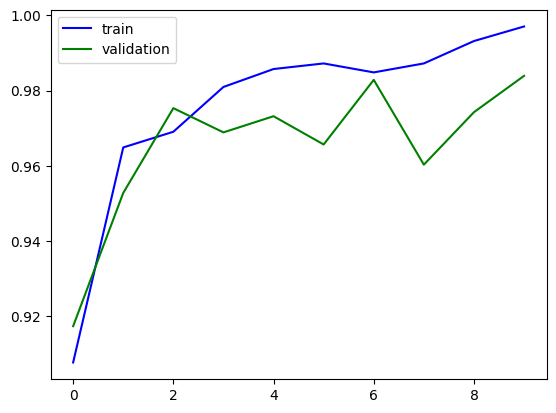

In [9]:
#accuarcy train v/s validation
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='blue',label='train')
plt.plot(history.history['val_accuracy'],color='green',label='validation')
plt.legend()
plt.show()

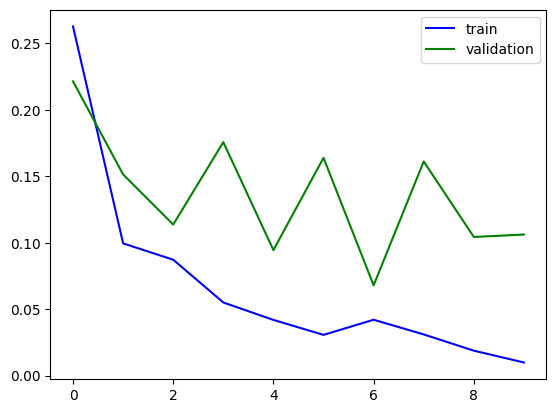

In [10]:
#loss train v/s validation
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],color='blue',label='train')
plt.plot(history.history['val_loss'],color='green',label='validation')
plt.legend()
plt.show()

In [11]:
#saving model
model.save('tuberculosis.h5')

In [12]:
#loading the saved model
from tensorflow.keras.models import load_model
model=load_model('tuberculosis.h5')